In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:

orders        = pd.read_csv(r"D:\projects\Brazilian E-Commerce Public Dataset\data\raw\olist_orders_dataset.csv")
customers     = pd.read_csv(r"D:\projects\Brazilian E-Commerce Public Dataset\data\raw\olist_customers_dataset.csv")
order_items   = pd.read_csv(r"D:\projects\Brazilian E-Commerce Public Dataset\data\raw\olist_order_items_dataset.csv")
payments      = pd.read_csv(r"D:\projects\Brazilian E-Commerce Public Dataset\data\raw\olist_order_payments_dataset.csv")
reviews       = pd.read_csv(r"D:\projects\Brazilian E-Commerce Public Dataset\data\raw\olist_order_reviews_dataset.csv")
products      = pd.read_csv(r"D:\projects\Brazilian E-Commerce Public Dataset\data\raw\olist_products_dataset.csv")
sellers       = pd.read_csv(r"D:\projects\Brazilian E-Commerce Public Dataset\data\raw\olist_sellers_dataset.csv")
category_tr   = pd.read_csv(r"D:\projects\Brazilian E-Commerce Public Dataset\data\raw\product_category_name_translation.csv")
geolocation   = pd.read_csv(r"D:\projects\Brazilian E-Commerce Public Dataset\data\raw\olist_geolocation_dataset.csv")

# Size check
tables = {
    "orders": orders, "customers": customers, "order_items": order_items,
    "payments": payments, "reviews": reviews, "products": products,
    "sellers": sellers, "category_tr": category_tr, "geolocation": geolocation,
}
for name, df in tables.items():
    print(f"{name:15s} → {df.shape[0]:>8,} rows | {df.shape[1]} cols")

orders          →   99,441 rows | 8 cols
customers       →   99,441 rows | 5 cols
order_items     →  112,650 rows | 7 cols
payments        →  103,886 rows | 5 cols
reviews         →   99,224 rows | 7 cols
products        →   32,951 rows | 9 cols
sellers         →    3,095 rows | 4 cols
category_tr     →       71 rows | 2 cols
geolocation     → 1,000,163 rows | 5 cols


orders and customers share the exact same 99,441 row count — 1:1 mapping with no orphaned customer records.
order_items (112,650) outnumber orders (99,441), averaging ~1.13 items per order — the bulk of purchases are single-item transactions.
All eight columns in the orders table load as strings, including timestamps — explicit datetime casting will be needed before any time-series work.
reviews (99,224) falls slightly short of orders (99,441), meaning ~217 orders have no review record at all.
geolocation dwarfs every other table at 1M rows — heavy deduplication will be required before it's usable for joins.

Taking sample 10000 rows

In [48]:

def explore_table(name, df):
    print("=" * 60)
    print(f"TABLE: {name}  |  Shape: {df.shape}")
    print("=" * 60)
    print("\n--- First 3 rows ---")
    print(df.head(3))
    print("\n--- Column dtypes ---")
    print(df.dtypes)
    print("\n")

explore_table("orders", orders)

TABLE: orders  |  Shape: (99441, 8)

--- First 3 rows ---
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   
2          2018-08-08 13:50:00           2018-08-17 18:06:29   

  order_estimated_delivery_date  
0           2017-10-18 00:00:00  
1           2018-08-13 00:00:00  
2           2018-09-04 00:00:00  

In [49]:

explore_table("customers", customers)

TABLE: customers  |  Shape: (99441, 5)

--- First 3 rows ---
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  

--- Column dtypes ---
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object




In [50]:

explore_table("geolocation", geolocation)

TABLE: geolocation  |  Shape: (1000163, 5)

--- First 3 rows ---
   geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                         1037       -23.545621       -46.639292   
1                         1046       -23.546081       -46.644820   
2                         1046       -23.546129       -46.642951   

  geolocation_city geolocation_state  
0        sao paulo                SP  
1        sao paulo                SP  
2        sao paulo                SP  

--- Column dtypes ---
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                   str
geolocation_state                  str
dtype: object




In [51]:


explore_table("order_items", order_items)

TABLE: order_items  |  Shape: (112650, 7)

--- First 3 rows ---
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   

   shipping_limit_date  price  freight_value  
0  2017-09-19 09:45:35   58.9          13.29  
1  2017-05-03 11:05:13  239.9          19.93  
2  2018-01-18 14:48:30  199.0          17.87  

--- Column dtypes ---
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float6

In [52]:
explore_table("payments", payments)

TABLE: payments  |  Shape: (103886, 5)

--- First 3 rows ---
                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  

--- Column dtypes ---
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object




In [53]:
explore_table("review", reviews)

TABLE: review  |  Shape: (99224, 7)

--- First 3 rows ---
                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   

   review_score review_comment_title review_comment_message  \
0             4                  NaN                    NaN   
1             5                  NaN                    NaN   
2             5                  NaN                    NaN   

  review_creation_date review_answer_timestamp  
0  2018-01-18 00:00:00     2018-01-18 21:46:59  
1  2018-03-10 00:00:00     2018-03-11 03:05:13  
2  2018-02-17 00:00:00     2018-02-18 14:36:24  

--- Column dtypes ---
review_id                    str
order_id                     str
review_score               int64
review_comment_title         str
review_comment_message       str
review_creat

In [54]:
explore_table("products", sellers)

TABLE: products  |  Shape: (3095, 4)

--- First 3 rows ---
                          seller_id  seller_zip_code_prefix     seller_city  \
0  3442f8959a84dea7ee197c632cb2df15                   13023        campinas   
1  d1b65fc7debc3361ea86b5f14c68d2e2                   13844      mogi guacu   
2  ce3ad9de960102d0677a81f5d0bb7b2d                   20031  rio de janeiro   

  seller_state  
0           SP  
1           SP  
2           RJ  

--- Column dtypes ---
seller_id                   str
seller_zip_code_prefix    int64
seller_city                 str
seller_state                str
dtype: object




In [55]:
explore_table("sellers", sellers)

TABLE: sellers  |  Shape: (3095, 4)

--- First 3 rows ---
                          seller_id  seller_zip_code_prefix     seller_city  \
0  3442f8959a84dea7ee197c632cb2df15                   13023        campinas   
1  d1b65fc7debc3361ea86b5f14c68d2e2                   13844      mogi guacu   
2  ce3ad9de960102d0677a81f5d0bb7b2d                   20031  rio de janeiro   

  seller_state  
0           SP  
1           SP  
2           RJ  

--- Column dtypes ---
seller_id                   str
seller_zip_code_prefix    int64
seller_city                 str
seller_state                str
dtype: object




In [56]:
explore_table("category_tr", category_tr)

TABLE: category_tr  |  Shape: (71, 2)

--- First 3 rows ---
    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto

--- Column dtypes ---
product_category_name            str
product_category_name_english    str
dtype: object




In [57]:
orders_s = orders.sample(n=10000, random_state = 42).reset_index(drop=True)

order_ids = set(orders_s["order_id"])
customer_ids = set(orders_s["customer_id"])

customers_s = customers[customers["customer_id"].isin(customer_ids)].copy()
order_items_s = order_items[order_items["order_id"].isin(order_ids)].copy()
payments_s = payments[payments["order_id"].isin(order_ids)].copy()
reviews_s = reviews[reviews["order_id"].isin(order_ids)].copy()

product_ids = set(order_items_s["product_id"])
products_s = products[products["product_id"].isin(product_ids)].copy()

seller_ids = set(order_items_s["seller_id"])
sellers_s = sellers[sellers["seller_id"].isin(seller_ids)].copy()

category_tr_s = category_tr.copy()

zip_codes = set(customers_s["customer_zip_code_prefix"]) | set(sellers_s["seller_zip_code_prefix"])
geolocation_s = geolocation[geolocation["geolocation_zip_code_prefix"].isin(zip_codes)].copy()

sampled= {
    "orders" : orders_s, "customers" : customers_s, "order_items" : order_items_s,
    "payments": payments_s, "reviews": reviews_s, "products": products_s,
    "sellers": sellers_s, "category_tr": category_tr_s, "geolocation": geolocation_s,
}

print("AFTER SAMPLING:")
for name, df in sampled.items():
    print(f"{name:15s} -> {df.shape[0]:>7,} rows")





AFTER SAMPLING:
orders          ->  10,000 rows
customers       ->  10,000 rows
order_items     ->  11,383 rows
payments        ->  10,476 rows
reviews         ->   9,959 rows
products        ->   6,747 rows
sellers         ->   1,654 rows
category_tr     ->      71 rows
geolocation     -> 650,746 rows


##Geo Dedupe

In [58]:
def most_frequent(series):
    m = series.mode()
    return m.iloc[0] if not m.empty else np.nan

geo_clean = (
    geolocation_s
    .groupby("geolocation_zip_code_prefix")
    .agg(
        geolocation_lat = ("geolocation_lat", "mean"),
        gelocation_lng = ("geolocation_lng", "mean"),
        geolocation_city = ("geolocation_city", most_frequent),
        geolocation_state = ("geolocation_state", most_frequent),
    )
    .reset_index()
)

print("Before:", geolocation_s.shape[0], "rows")
print("After:", geo_clean.shape[0], "rows (1 per zip)")
geo_clean.head()

    

Before: 650746 rows
After: 6486 rows (1 per zip)


,geolocation_zip_code_prefix,geolocation_lat,gelocation_lng,geolocation_city,geolocation_state
0,1001,-23.550190,-46.634024,sao paulo,SP
1,1005,-23.549456,-46.636733,sao paulo,SP
2,1006,-23.550102,-46.636137,sao paulo,SP
3,1007,-23.550046,-46.637251,sao paulo,SP
4,1008,-23.546002,-46.635886,sao paulo,SP


650K raw geolocation rows collapse to just 6,486 unique zip codes — each zip averaged ~100 duplicate coordinate entries in the source data.

In [59]:
sampled = {
    "orders": orders_s, "customers": customers_s, "order_items": order_items_s,
    "payments": payments_s, "reviews": reviews_s, "products": products_s,
    "sellers": sellers_s, "category_tr": category_tr_s, "geolocation": geo_clean,
}
print("AFTER SAMPLING:")
for name, df in sampled.items():
    print(f"{name:15s} → {df.shape[0]:>7,} rows")

AFTER SAMPLING:
orders          →  10,000 rows
customers       →  10,000 rows
order_items     →  11,383 rows
payments        →  10,476 rows
reviews         →   9,959 rows
products        →   6,747 rows
sellers         →   1,654 rows
category_tr     →      71 rows
geolocation     →   6,486 rows


In [60]:

save_folder = r"D:\projects\Brazilian E-Commerce Public Dataset\data\sampled data"  

for name, df in sampled.items():
    path = save_folder + "\\" + name + ".csv"
    df.to_csv(path, index=False)
    print("Saved →", path)

Saved → D:\projects\Brazilian E-Commerce Public Dataset\data\sampled data\orders.csv
Saved → D:\projects\Brazilian E-Commerce Public Dataset\data\sampled data\customers.csv
Saved → D:\projects\Brazilian E-Commerce Public Dataset\data\sampled data\order_items.csv
Saved → D:\projects\Brazilian E-Commerce Public Dataset\data\sampled data\payments.csv
Saved → D:\projects\Brazilian E-Commerce Public Dataset\data\sampled data\reviews.csv
Saved → D:\projects\Brazilian E-Commerce Public Dataset\data\sampled data\products.csv
Saved → D:\projects\Brazilian E-Commerce Public Dataset\data\sampled data\sellers.csv
Saved → D:\projects\Brazilian E-Commerce Public Dataset\data\sampled data\category_tr.csv
Saved → D:\projects\Brazilian E-Commerce Public Dataset\data\sampled data\geolocation.csv


\\Data Dictionary

In [61]:
rows = []
for tname, df in tables.items():
    for col in df.columns:
        rows.append({
            "table_name": tname,
            "column_name": col,
            "data_type": str(df[col].dtype),
            "non_null_count": df[col].notna().sum(),
            "missing_pct": round(df[col].isna().mean() * 100, 2),
            "unique_values": df[col].nunique(),
            "sample_value": df[col].dropna().iloc[0] if df[col].notna().any() else "",
            "description": ""   # business meaning — keezha fill pannuvom
        })

data_dict = pd.DataFrame(rows)
print("Total columns documented:", len(data_dict))
data_dict.head(10)


Total columns documented: 52


,table_name,column_name,data_type,non_null_count,missing_pct,unique_values,sample_value,description
0,orders,order_id,str,99441,0.00,99441,e481f51cbdc54678b7cc49136f2d6af7,
1,orders,customer_id,str,99441,0.00,99441,9ef432eb6251297304e76186b10a928d,
2,orders,order_status,str,99441,0.00,8,delivered,
3,orders,order_purchase_timestamp,str,99441,0.00,98875,2017-10-02 10:56:33,
4,orders,order_approved_at,str,99281,0.16,90733,2017-10-02 11:07:15,
5,orders,order_delivered_carrier_date,str,97658,1.79,81018,2017-10-04 19:55:00,
6,orders,order_delivered_customer_date,str,96476,2.98,95664,2017-10-10 21:25:13,
7,orders,order_estimated_delivery_date,str,99441,0.00,459,2017-10-18 00:00:00,
8,customers,customer_id,str,99441,0.00,99441,06b8999e2fba1a1fbc88172c00ba8bc7,
9,customers,customer_unique_id,str,99441,0.00,96096,861eff4711a542e4b93843c6dd7febb0,


In [62]:

descriptions = {
    "order_id": "Unique ID for each order (primary key)",
    "customer_id": "Links order to a customer (one per order)",
    "customer_unique_id": "Real customer identity across multiple orders",
    "order_status": "Order state: delivered, shipped, canceled, etc.",
    "order_purchase_timestamp": "When the customer placed the order",
    "order_approved_at": "When payment was approved",
    "order_delivered_carrier_date": "When order was handed to courier",
    "order_delivered_customer_date": "When order reached the customer",
    "order_estimated_delivery_date": "Promised delivery date",
    "customer_zip_code_prefix": "Customer location zip code",
    "customer_city": "Customer city",
    "customer_state": "Customer state (e.g. SP, RJ)",
    "order_item_id": "Item sequence number within an order",
    "product_id": "Unique product identifier",
    "seller_id": "Unique seller identifier",
    "shipping_limit_date": "Deadline for seller to ship",
    "price": "Product price",
    "freight_value": "Shipping cost",
    "payment_type": "credit_card, boleto, voucher, debit_card",
    "payment_installments": "Number of EMI installments",
    "payment_value": "Amount paid",
    "review_score": "Customer rating 1 to 5",
    "product_category_name": "Product category (Portuguese)",
    "product_category_name_english": "Product category (English)",
    "product_weight_g": "Product weight in grams",
    "geolocation_lat": "Latitude of zip code",
    "geolocation_lng": "Longitude of zip code",
    "seller_city": "Seller city",
    "seller_state": "Seller state",
}

# Map descriptions onto the dictionary
data_dict["description"] = data_dict["column_name"].map(descriptions).fillna("")

# Save as CSV 
out_folder = r"D:\projects\Brazilian E-Commerce Public Dataset\reports"
data_dict.to_csv(out_folder + r"\data_dictionary.csv", index=False)

print("Data Dictionary saved → reports\\data_dictionary.csv ✓")
print("Columns with description:", (data_dict['description'] != '').sum(), "/", len(data_dict))


data_dict

Data Dictionary saved → reports\data_dictionary.csv ✓
Columns with description: 36 / 52


,table_name,column_name,data_type,non_null_count,missing_pct,unique_values,sample_value,description
0,orders,order_id,str,99441,0.00,99441,e481f51cbdc54678b7cc49136f2d6af7,Unique ID for each order (primary key)
1,orders,customer_id,str,99441,0.00,99441,9ef432eb6251297304e76186b10a928d,Links order to a customer (one per order)
2,orders,order_status,str,99441,0.00,8,delivered,"Order state: delivered, shipped, canceled, etc."
3,orders,order_purchase_timestamp,str,99441,0.00,98875,2017-10-02 10:56:33,When the customer placed the order
4,orders,order_approved_at,str,99281,0.16,90733,2017-10-02 11:07:15,When payment was approved
5,orders,order_delivered_carrier_date,str,97658,1.79,81018,2017-10-04 19:55:00,When order was handed to courier
6,orders,order_delivered_customer_date,str,96476,2.98,95664,2017-10-10 21:25:13,When order reached the customer
7,orders,order_estimated_delivery_date,str,99441,0.00,459,2017-10-18 00:00:00,Promised delivery date
8,customers,customer_id,str,99441,0.00,99441,06b8999e2fba1a1fbc88172c00ba8bc7,Links order to a customer (one per order)
9,customers,customer_unique_id,str,99441,0.00,96096,861eff4711a542e4b93843c6dd7febb0,Real customer identity across multiple orders


- 52 columns are documented across 9 raw tables; orders alone holds 8 timestamp columns, all stored as strings — every date field needs explicit casting before any time-based query will work correctly.
- order_approved_at (0.16% missing), order_delivered_carrier_date (1.79%), and order_delivered_customer_date (2.98%) are the only null fields in the orders table — all three are structurally absent for orders that haven't reached those stages, not data entry errors.
- customer_unique_id has 96,096 unique values across 99,441 rows in the full dataset — roughly 3,345 customers placed more than one order, though this repeat-buyer signal is nearly invisible in the 10K sample.

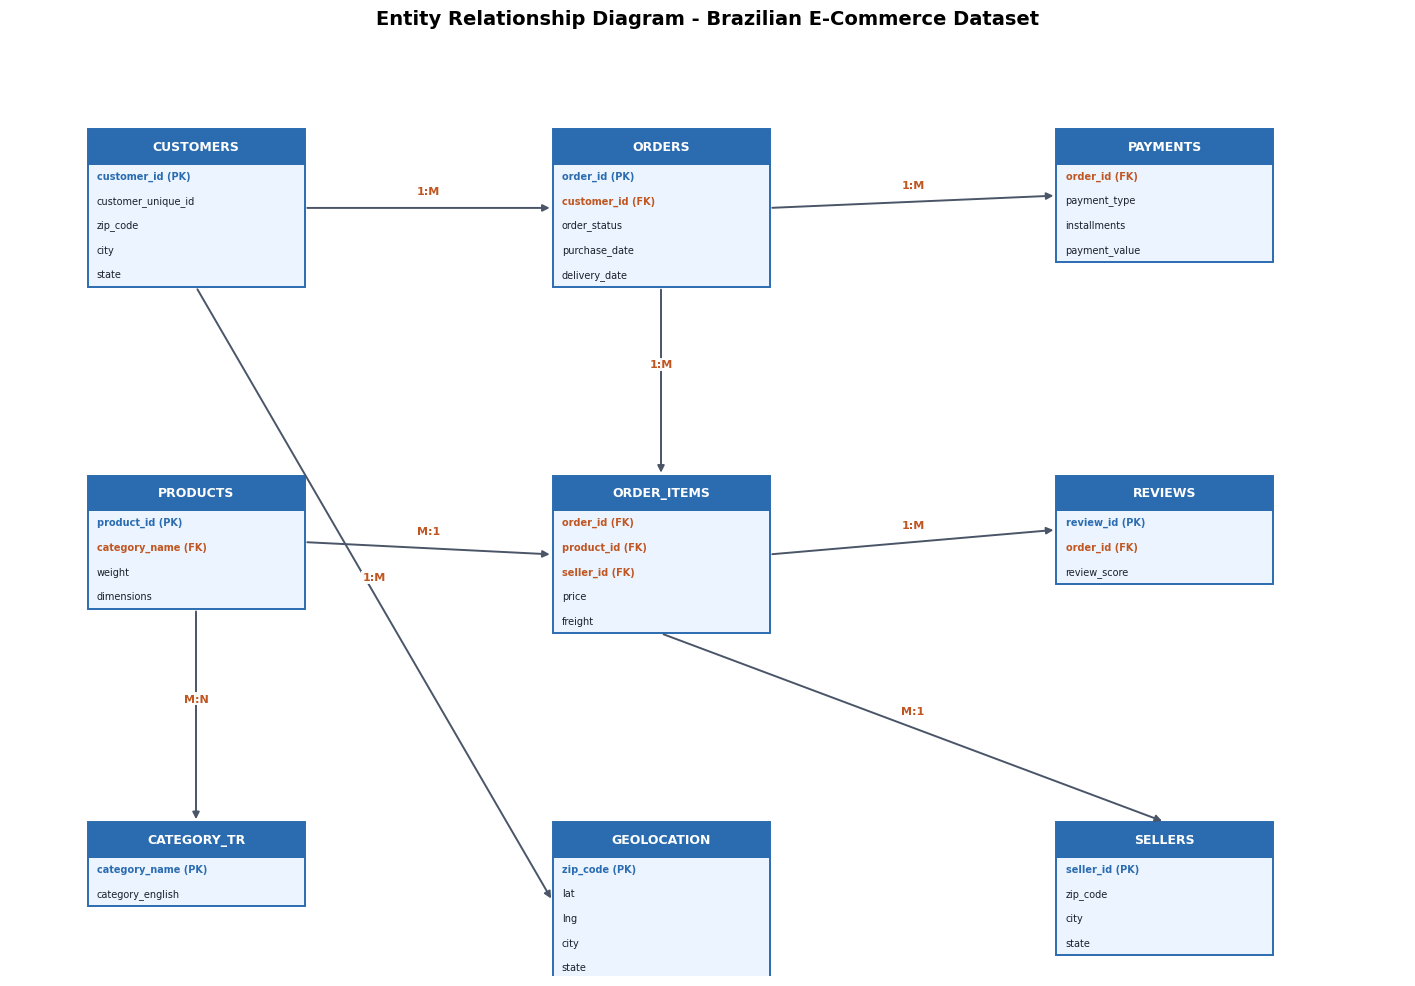

Saved -> reports/ER_diagram.png


In [68]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 12))
ax.set_xlim(0, 18); ax.set_ylim(0, 12); ax.axis("off")

BOX_W, HDR_H, ROW_H = 2.8, 0.45, 0.32
boxes = {}

def draw_table(name, columns, x, y_top):
    n = len(columns); body_h = n * ROW_H; total_h = HDR_H + body_h
    ax.add_patch(plt.Rectangle((x, y_top - total_h), BOX_W, body_h,
                               fc="#ebf4ff", ec="#2b6cb0", lw=1.4, zorder=2))
    ax.add_patch(plt.Rectangle((x, y_top - HDR_H), BOX_W, HDR_H,
                               fc="#2b6cb0", ec="#2b6cb0", lw=1.4, zorder=3))
    ax.text(x + BOX_W/2, y_top - HDR_H/2, name, ha="center", va="center",
            fontsize=9, fontweight="bold", color="white", zorder=4)
    for i, col in enumerate(columns):
        ry = y_top - HDR_H - (i + 0.5) * ROW_H
        color = "#2b6cb0" if "PK" in col else ("#c05621" if "FK" in col else "#1a202c")
        weight = "bold" if ("PK" in col or "FK" in col) else "normal"
        ax.text(x + 0.12, ry, col, ha="left", va="center",
                fontsize=7, color=color, fontweight=weight, zorder=4)
    boxes[name] = dict(L=x, R=x+BOX_W, T=y_top, B=y_top-total_h,
                       CX=x+BOX_W/2, CY=y_top-total_h/2)

def connect(t1, t2, label="", side1="R", side2="L"):
    b1, b2 = boxes[t1], boxes[t2]
    pts = {"L": (b1["L"], b1["CY"]), "R": (b1["R"], b1["CY"]),
           "T": (b1["CX"], b1["T"]), "B": (b1["CX"], b1["B"])}
    pte = {"L": (b2["L"], b2["CY"]), "R": (b2["R"], b2["CY"]),
           "T": (b2["CX"], b2["T"]), "B": (b2["CX"], b2["B"])}
    x1, y1 = pts[side1]; x2, y2 = pte[side2]
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color="#4a5568", lw=1.4))
    if label:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.15, label, ha="center", va="bottom",
                fontsize=8, color="#c05621", fontweight="bold",
                bbox=dict(fc="white", ec="none", alpha=0.95, pad=1))

# tables
draw_table("CUSTOMERS", ["customer_id (PK)", "customer_unique_id",
                         "zip_code", "city", "state"], 1.0, 11.0)
draw_table("ORDERS", ["order_id (PK)", "customer_id (FK)", "order_status",
                      "purchase_date", "delivery_date"], 7.0, 11.0)
draw_table("PAYMENTS", ["order_id (FK)", "payment_type",
                        "installments", "payment_value"], 13.5, 11.0)
draw_table("ORDER_ITEMS", ["order_id (FK)", "product_id (FK)",
                           "seller_id (FK)", "price", "freight"], 7.0, 6.5)
draw_table("REVIEWS", ["review_id (PK)", "order_id (FK)",
                       "review_score"], 13.5, 6.5)
draw_table("PRODUCTS", ["product_id (PK)", "category_name (FK)",
                        "weight", "dimensions"], 1.0, 6.5)
draw_table("SELLERS", ["seller_id (PK)", "zip_code",
                       "city", "state"], 13.5, 2.0)
draw_table("CATEGORY_TR", ["category_name (PK)",
                           "category_english"], 1.0, 2.0)
draw_table("GEOLOCATION", ["zip_code (PK)", "lat", "lng",
                           "city", "state"], 7.0, 2.0)

# relationships
connect("CUSTOMERS", "ORDERS", "1:M", "R", "L")
connect("ORDERS", "ORDER_ITEMS", "1:M", "B", "T")
connect("ORDERS", "PAYMENTS", "1:M", "R", "L")
connect("ORDER_ITEMS", "REVIEWS", "1:M", "R", "L")
connect("PRODUCTS", "ORDER_ITEMS", "M:1", "R", "L")
connect("ORDER_ITEMS", "SELLERS", "M:1", "B", "T")
connect("PRODUCTS", "CATEGORY_TR", "M:N", "B", "T")
connect("CUSTOMERS", "GEOLOCATION", "1:M", "B", "L")

ax.set_title("Entity Relationship Diagram - Brazilian E-Commerce Dataset",
             fontsize=14, fontweight="bold", pad=20)
plt.savefig(r"D:\projects\Brazilian E-Commerce Public Dataset\reports\ER_diagram.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> reports/ER_diagram.png")

- orders sits at the centre of the schema — it connects directly to customers, order_items, payments, and reviews, making order_id the primary join key that threads through the entire dataset.
- order_items is the most connected node in the diagram — it simultaneously holds foreign keys to orders, products, and sellers, making it the only table that bridges the customer journey with the supplier side.
- geolocation and category_tr are pure lookup tables with no outbound foreign keys; they enrich customer and product records but don't anchor any facts, so they can be dropped from analyses that don't need geographic or language context.